# Learnings
### torch.tensor(np_array, dtype=torch.float32orint32) : converts np_array to tensor
### torch.tensor(padas_series.values (converte serires to nparray), dtype=tensore.`type).view(-1,1)
- first -1 : auto detect rows and second 1 makes the column number 

# Steps
- dataframe
- X, y slit
- X_Train, y_train
- X_train_scaled, ..so_on
- tensor converstion

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("powerplant_data.csv")
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop("PE", axis=1)
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [5]:
y = df["PE"]
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [6]:
df.shape

(9568, 5)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.head()

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85


In [9]:
print(type(y_test))
y_test.head()

<class 'pandas.core.series.Series'>


2513    433.27
9411    438.16
8745    458.42
9085    480.82
4950    441.41
Name: PE, dtype: float64

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [11]:
print(y_train.shape)
type(y_train)

(7654,)


pandas.core.series.Series

In [12]:
type(y_train.values)

numpy.ndarray

In [13]:
import torch 
import torch.nn as nn

In [14]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)   # numpy array could be directly converted into tensors
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# but pandas series or dataFrame could not be directly converted to tensors rather there values are extracted which in collection becomes array
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)    
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [15]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [16]:
y_test_tensor

tensor([[433.2700],
        [438.1600],
        [458.4200],
        ...,
        [467.8000],
        [437.1400],
        [456.7800]])

In [17]:
from torch.utils.data import TensorDataset, DataLoader

In [18]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)         # takes input_features , output_features
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)            # takes dataset, batch_size and shuffle
test_loader = DataLoader(test_dataset, batch_size=32)

In [20]:
X_train.shape[1]

4

In [21]:
# Define the ANN
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # 3rd Output Layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [22]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [23]:
# Train the ANN
train_losses = []
val_losses = []
epochs = 100
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    running_loss=0.0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()   # fresh gradient by making old one zero
        
        outputs = model(xb)   # Forward Propagation feeding data 
        loss = criterion(outputs, yb)   #loss
        loss.backward()  # Backward Propagation computing gradients 
        optimizer.step() # update weights and bias
        
        running_loss+=loss.item() # loss was tensor so .item() converts it into float.

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    

    model.eval()    # converting model to evalute mode
    running_val_loss=0.0
    with torch.no_grad():  # during validation no need to to compute gradient and use optimizer
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss+=loss.item()

        epoch_val_loss = running_val_loss / len(test_loader)   
        val_losses.append(epoch_val_loss)    

    print(f"Epoch = {epoch+1} ==> Training Loss = {epoch_train_loss} and Testing Loss = {epoch_val_loss}")    

    if(epoch_val_loss < best_val_loss):
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth file types are used to save the lear

Epoch = 1 ==> Training Loss = 206226.80201822918 and Testing Loss = 204858.16770833332
Epoch = 2 ==> Training Loss = 198772.76028645833 and Testing Loss = 187619.04609375
Epoch = 3 ==> Training Loss = 166099.44915364584 and Testing Loss = 139871.45729166668
Epoch = 4 ==> Training Loss = 108686.74973958333 and Testing Loss = 78500.66614583334
Epoch = 5 ==> Training Loss = 54401.81787923177 and Testing Loss = 36083.89654947917
Epoch = 6 ==> Training Loss = 26236.24138590495 and Testing Loss = 20060.83709309896
Epoch = 7 ==> Training Loss = 16956.89696044922 and Testing Loss = 14725.1140625
Epoch = 8 ==> Training Loss = 13049.524692789713 and Testing Loss = 11508.33155110677
Epoch = 9 ==> Training Loss = 10110.440561930338 and Testing Loss = 8795.74999186198
Epoch = 10 ==> Training Loss = 7600.17397664388 and Testing Loss = 6481.9324666341145
Epoch = 11 ==> Training Loss = 5526.4396280924475 and Testing Loss = 4648.239754231771
Epoch = 12 ==> Training Loss = 3921.1070902506513 and Testing

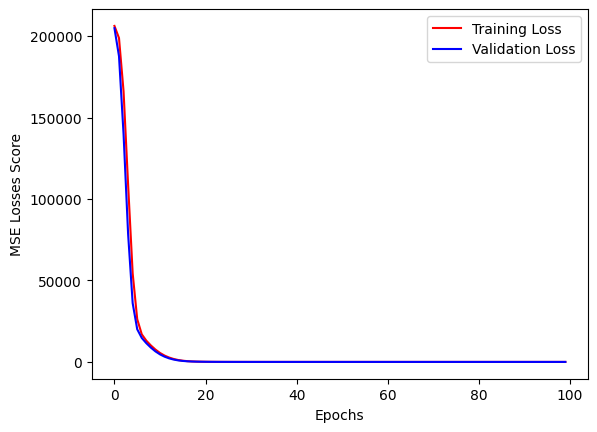

In [24]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Testing Loss": val_losses
})

plt.plot(loss_df["Training Loss"], color="red", label="Training Loss")
plt.plot(loss_df["Testing Loss"], color="blue", label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("MSE Losses Score")

plt.legend()

In [ ]:
# Load the saved model
model.load_state_dict(torch.load("best_model.pt"))

C:\Users\mihir\AppData\Local\Temp\ipykernel_1572\1885814325.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>